This program is used to calculate the curvature of an airfoil

In [172]:
def find_low_curvature_regions(airfoil, chord_length, curvature_threshold, rear_exclusion=0.2, plotting_enabled=True, printing_enabled=True, interpolation_factor=20):
    from scipy.interpolate import CubicSpline

    # Normalize and scale a copy of the airfoil coordinates to the chord length.
    scaled_airfoil = airfoil.copy()
    initial_scale = scaled_airfoil['x'].max()
    scaled_airfoil['x'] = scaled_airfoil['x'] / initial_scale * chord_length
    scaled_airfoil['y'] = scaled_airfoil['y'] / initial_scale * chord_length

    # Parameterize the airfoil by cumulative distance along its original points.
    original_points = scaled_airfoil[['x', 'y']].to_numpy()
    original_lengths = np.linalg.norm(np.diff(original_points, axis=0), axis=1)
    original_parameter = np.concatenate(([0], np.cumsum(original_lengths)))

    # Interpolate the curve and its derivatives at a much finer resolution.
    interpolated_count = max(len(original_points) * interpolation_factor, 2000)
    interpolation_parameter = np.linspace(0, original_parameter[-1], interpolated_count)
    spline = CubicSpline(original_parameter, original_points, axis=0)
    points = spline(interpolation_parameter)
    first_derivative = spline(interpolation_parameter, 1)
    second_derivative = spline(interpolation_parameter, 2)

    # Calculate curvature from the first and second derivatives of the spline.
    cross_product = (
        first_derivative[:, 0] * second_derivative[:, 1]
        - first_derivative[:, 1] * second_derivative[:, 0]
    )
    derivative_magnitude = np.linalg.norm(first_derivative, axis=1)
    curvature = np.abs(cross_product) / derivative_magnitude**3

    # Build one line segment per pair of neighboring interpolated points.
    segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
    segment_curvature = (curvature[:-1] + curvature[1:]) / 2
    segment_lengths = np.linalg.norm(segments[:, 1] - segments[:, 0], axis=1)

    # Exclude the rear section and identify low-curvature interpolated segments.
    cutoff_x = (1 - rear_exclusion) * chord_length
    segment_midpoints = (segments[:, 0] + segments[:, 1]) / 2
    below_threshold = segment_curvature < curvature_threshold
    before_cutoff = segment_midpoints[:, 0] < cutoff_x
    below_threshold = np.logical_and(below_threshold, before_cutoff)

    # Find contiguous runs of interpolated segments below the threshold.
    all_regions = []
    region_start = None
    for segment_index, is_below_threshold in enumerate(np.append(below_threshold, False)):
        if is_below_threshold and region_start is None:
            region_start = segment_index
        elif not is_below_threshold and region_start is not None:
            region_end = segment_index
            region_length = segment_lengths[region_start:region_end].sum()
            all_regions.append((region_start, region_end, region_length))
            region_start = None

    # Keep only regions on the upper surface; lower-surface regions are ignored.
    regions = [
        region for region in all_regions
        if np.mean(points[region[0]:region[1] + 1, 1]) >= 0
    ]

    if printing_enabled:
        print(f'Maximum curvature: {curvature.max():.6f} at (x,y) = {points[curvature.argmax()]}')
        print(f'Upper-surface regions with curvature < {curvature_threshold}:')
    largest_region_length = 0.0
    for region_number, (_, _, region_length) in enumerate(regions, start=1):
        if printing_enabled:
            print(f'  Region {region_number}: {region_length:.6f}')
        largest_region_length = max(largest_region_length, region_length)

    if plotting_enabled:
        # Plot the interpolated airfoil, colored according to curvature.
        fig, ax = plt.subplots(figsize=(20, 3))
        positive_curvature = segment_curvature[segment_curvature > 0]
        norm = colors.LogNorm(vmin=positive_curvature.min(), vmax=segment_curvature.max())
        line = LineCollection(segments, cmap='viridis', norm=norm, linewidth=2)
        line.set_array(segment_curvature)
        ax.add_collection(line)

        # Mark every continuous upper-surface region below the threshold in crimson.
        for region_start, region_end, _ in regions:
            marked_region = LineCollection(
                segments[region_start:region_end], colors='crimson', linewidth=4
            )
            ax.add_collection(marked_region)

        ax.autoscale()
        ax.set_aspect('equal')
        fig.colorbar(line, ax=ax, label='Curvature')
        ax.plot([], [], color='crimson', linewidth=4, label=f'Upper surface, curvature < {curvature_threshold}')
        ax.vlines(x=cutoff_x, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='orange', linestyle='--', label=f'Exclusion zone start at {1 - rear_exclusion:.0%} chord')
        ax.set_title(f'Airfoil Curvature Visualization ({interpolation_factor}x interpolation)')
        ax.legend(loc='upper right')
        plt.show()

    # Return the length of the largest region.
    return largest_region_length


C:\Users\Graham\AppData\Local\Temp\ipykernel_30220\3706057575.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  length = fsolve(curv_function, chord_length)


Optimal chord length for solar panel: 9.671921
Maximum curvature: 20.519766 at (x,y) = [ 0.00040994 -0.00402271]
Upper-surface regions with curvature < 0.2:
  Region 1: 6.250000


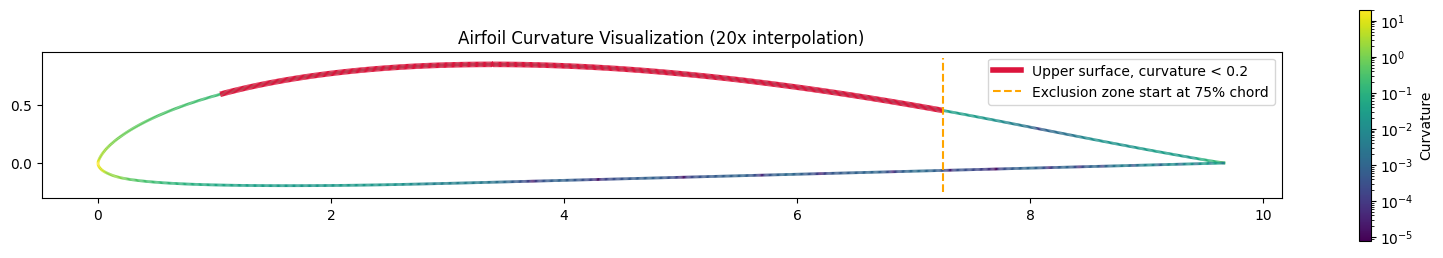

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as colors
from scipy.optimize import fsolve

airfoil = pd.read_csv('airfoils/s7055.csv', header=0, names=['x', 'y'])



# Normalize the airfoil coordinates to the range [0, 1]
chord_length = 10.0 # Any units
airfoil = airfoil / np.max(airfoil['x']) * chord_length
curvature_threshold = 0.2 # Same units as chord length
rear_exclusion = 0.25 # Exclude the last X% of the airfoil from the panel region
solar_panel_length = 6.25

def curv_function(chord_length):
    return solar_panel_length - find_low_curvature_regions(airfoil, chord_length, curvature_threshold, rear_exclusion, plotting_enabled=False, printing_enabled=False)

length = fsolve(curv_function, chord_length)

print(f'Optimal chord length for solar panel: {length[0]:.6f}')
_ = find_low_curvature_regions(airfoil, length, curvature_threshold, rear_exclusion, plotting_enabled=True, printing_enabled=True)
